In [33]:
import tensorflow as tf
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet import preprocess_input

In [34]:
keras_model_path = r"D:\Final Year\Sem 2\Major Project\Model Project\Model B (Keras Tensorflow)\keras_model_with_5k_images.h5"
pytorch_model_path = r"D:\Final Year\Sem 2\Major Project\Model Project\Model A (MobileNet)\mobilenet_model.pth"
student_model_path = r"D:\Final Year\Sem 2\Major Project\Model Project\baseStudentModel\student_model.h5"

val_path = r"D:\Final Year\Sem 2\Major Project\Model Project\Dataset\valid\images"

In [35]:
IMG_SIZE = 224
BATCH_SIZE = 32

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = val_data.class_names

val_data = val_data.map(lambda x, y: (preprocess_input(x), y))

Found 2000 files belonging to 2 classes.


In [36]:
keras_model = load_model(keras_model_path)

In [37]:
student_model = load_model(student_model_path)

In [38]:
pytorch_model = models.mobilenet_v2(pretrained=False)

pytorch_model.classifier[1] = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(pytorch_model.last_channel, 2)
)

pytorch_model.load_state_dict(
    torch.load(pytorch_model_path, map_location=torch.device('cpu')),
    strict=True
)

pytorch_model.eval()

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\temp\ipykernel_12192\365145030.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `w

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [39]:
keras_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

student_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
loss_k, acc_k = keras_model.evaluate(val_data)
loss_s, acc_s = student_model.evaluate(val_data)

63/63 [==============================] - 40s 608ms/step - loss: 0.0329 - accuracy: 0.9900


In [41]:
val_data_raw = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 2000 files belonging to 2 classes.


In [42]:
import torchvision.transforms as transforms

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

correct = 0
total = 0

for images, labels in val_data_raw:

    torch_images = torch.from_numpy(images.numpy()).permute(0,3,1,2).float() / 255.0

    # ✅ Apply PyTorch normalization correctly
    torch_images = torch.stack([normalize(img) for img in torch_images])

    labels_np = np.argmax(labels.numpy(), axis=1)

    with torch.no_grad():
        outputs = pytorch_model(torch_images)
        preds = torch.argmax(outputs, dim=1).numpy()

    correct += np.sum(preds == labels_np)
    total += len(labels_np)

acc_p = correct / total

In [43]:
print("\n========== MODEL COMPARISON ==========")
print(f"Keras Model Accuracy      : {acc_k*100:.2f}%")
print(f"PyTorch Model Accuracy    : {acc_p*100:.2f}%")
print(f"Hybrid/Student Accuracy   : {acc_s*100:.2f}%")
print("=====================================")


========== MODEL COMPARISON ==========
Keras Model Accuracy      : 98.30%
PyTorch Model Accuracy    : 89.40%
Hybrid/Student Accuracy   : 99.00%


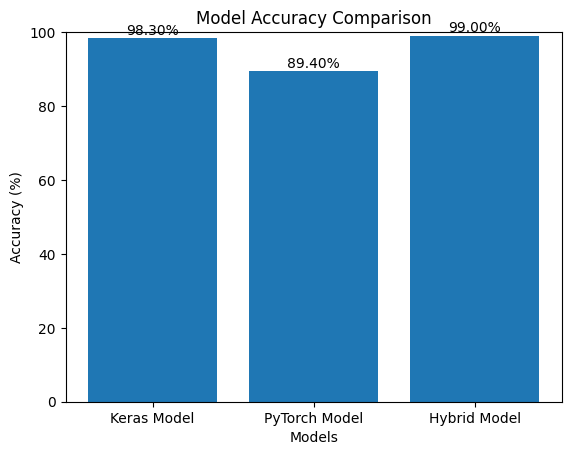

In [44]:
import matplotlib.pyplot as plt

models = ['Keras Model', 'PyTorch Model', 'Hybrid Model']
accuracies = [acc_k*100, acc_p*100, acc_s*100]

plt.figure()
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

# Add value labels on top
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.ylim(0, 100)
plt.show()